In [116]:
import torch
import sklearn
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

In [117]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

torch  : 2.7.1
sklearn: 1.5.1
pandas : 2.2.2
numpy  : 1.26.4



In [118]:
arquivo = "C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/Dados/dataset_vendas2.csv"
dados_vendas = pd.read_csv(arquivo, usecols = [1], engine = 'python')

In [119]:
dados_vendas.shape

(144, 1)

In [120]:
dados_vendas.head()

,Unidades_Vendidas
0,112
1,118
2,132
3,129
4,121


<Axes: >

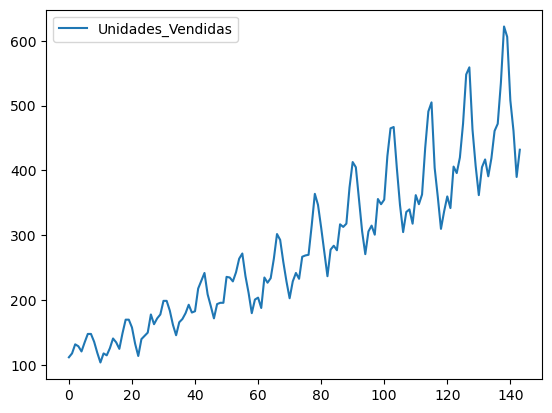

In [121]:
dados_vendas.plot()

In [122]:
dataset = dados_vendas.values.astype('float32')

In [123]:
dataset[0:5]

array([[112.],
       [118.],
       [132.],
       [129.],
       [121.]], dtype=float32)

In [124]:
scaler = MinMaxScaler(feature_range = (0, 1))

In [125]:
dataset = scaler.fit_transform(dataset)

In [126]:
tamanho_treino = int(len(dataset) * 0.67)
test_size = len(dataset) - tamanho_treino
dados_treino, dados_teste = dataset[0:tamanho_treino], dataset[tamanho_treino:]

In [127]:
len(dados_treino)

96

In [128]:
len(dados_teste)

48

In [129]:
def create_dataset(data, window_size):
    X, Y = [], []

    for i in range(len(data) - window_size - 1):
        a = data[i:(i + window_size), 0]
        X.append(a)
        Y.append(data[i + window_size, 0 ])
    return np.array(X), np.array(Y)

In [130]:
window_size = 12

In [131]:
X_treino, Y_treino = create_dataset(dados_treino, window_size)
X_teste, Y_teste = create_dataset(dados_teste, window_size)

In [132]:
X_treino

array([[0.01544401, 0.02702703, 0.05405405, 0.04826255, 0.03281853,
        0.05984557, 0.08494207, 0.08494207, 0.06177607, 0.02895753,
        0.        , 0.02702703],
       [0.02702703, 0.05405405, 0.04826255, 0.03281853, 0.05984557,
        0.08494207, 0.08494207, 0.06177607, 0.02895753, 0.        ,
        0.02702703, 0.02123553],
       [0.05405405, 0.04826255, 0.03281853, 0.05984557, 0.08494207,
        0.08494207, 0.06177607, 0.02895753, 0.        , 0.02702703,
        0.02123553, 0.04247104],
       [0.04826255, 0.03281853, 0.05984557, 0.08494207, 0.08494207,
        0.06177607, 0.02895753, 0.        , 0.02702703, 0.02123553,
        0.04247104, 0.07142857],
       [0.03281853, 0.05984557, 0.08494207, 0.08494207, 0.06177607,
        0.02895753, 0.        , 0.02702703, 0.02123553, 0.04247104,
        0.07142857, 0.05984557],
       [0.05984557, 0.08494207, 0.08494207, 0.06177607, 0.02895753,
        0.        , 0.02702703, 0.02123553, 0.04247104, 0.07142857,
        0.05984557,

In [133]:
Y_treino

array([0.02123553, 0.04247104, 0.07142857, 0.05984557, 0.04054055,
       0.08687258, 0.12741312, 0.12741312, 0.10424709, 0.05598456,
       0.01930502, 0.06949806, 0.07915059, 0.08880308, 0.14285713,
       0.11389962, 0.13127413, 0.14285713, 0.18339768, 0.18339768,
       0.15444016, 0.11196911, 0.08108109, 0.1196911 , 0.12934363,
       0.14671814, 0.17181468, 0.14864865, 0.15250966, 0.22007722,
       0.24324325, 0.26640925, 0.2027027 , 0.16795367, 0.13127413,
       0.17374519, 0.17760617, 0.17760617, 0.25482625, 0.25289574,
       0.24131274, 0.26833975, 0.3088803 , 0.32432434, 0.25675675,
       0.20656371, 0.14671814, 0.18725869, 0.19305018, 0.16216215,
       0.25289574, 0.23745173, 0.25096524, 0.3088803 , 0.38223937,
       0.36486486, 0.2992278 , 0.24131274, 0.1911197 , 0.24131274,
       0.26640925, 0.24903473, 0.31467178, 0.3185328 , 0.32046333,
       0.4073359 , 0.5019305 , 0.46911195, 0.40154442, 0.32818535,
       0.25675675, 0.3359073 , 0.34749034, 0.33397684, 0.41119

In [134]:
X_treino = torch.from_numpy(X_treino).float()
Y_treino = torch.from_numpy(Y_treino).float()
X_teste = torch.from_numpy(X_teste).float()
Y_teste = torch.from_numpy(Y_teste).float()

In [135]:
class TimeSeriesDataset(Dataset):
    
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [136]:
train_dataset = TimeSeriesDataset(X_treino, Y_treino)
test_dataset = TimeSeriesDataset(X_teste, Y_teste)

In [137]:
train_loader = DataLoader(train_dataset, batch_size = 1, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 1, shuffle = False)

In [138]:
class TimeSeriesTransformer(nn.Module):

    def __init__(self, input_dim, model_dim, num_heads, num_layers, dropout = 0.1):

        super().__init__()
        
        self.embedding = nn.Linear(input_dim, model_dim)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model = model_dim, nhead = num_heads, dropout = dropout)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers = num_layers)
        self.linear = nn.Linear(model_dim, 1)

    def forward(self, x): 
        x = self.embedding(x)
        x = x.permute(1, 0, 2)
        x = self.transformer_encoder(x)
        x = self.linear(x)
        x = x.permute(1, 0, 2)
        return x[:, -1, :]


In [139]:
input_dim = 1
model_dim = 64
num_heads = 4
num_layers = 2
taxa_aprendizado = 0.001

In [140]:
model = TimeSeriesTransformer(input_dim, model_dim, num_heads, num_layers)

C:\Users\conta\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [141]:
criterion = nn.MSELoss()

In [142]:
optimizer = optim.Adam(model.parameters(), lr = taxa_aprendizado)

In [143]:
def treina_modelo(model,  train_loader, criterion, optimizer, num_epochs = 50):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs = inputs.unsqueeze(-1)
            labels = labels.unsqueeze(-1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f'Epoch {epoch + 1}/{num_epochs}, Erro: {running_loss / len(train_loader)}')


In [154]:
treina_modelo(model, train_loader, criterion, optimizer, num_epochs = 50)

Epoch 1/50, Erro: 0.019686853858972033
Epoch 2/50, Erro: 0.01953742068173976
Epoch 3/50, Erro: 0.01982273489688467
Epoch 4/50, Erro: 0.019941004974785997
Epoch 5/50, Erro: 0.020518423499515298
Epoch 6/50, Erro: 0.019237145472738623
Epoch 7/50, Erro: 0.019938363181356993
Epoch 8/50, Erro: 0.018879162849051646
Epoch 9/50, Erro: 0.01655709325186862
Epoch 10/50, Erro: 0.0216703734841357
Epoch 11/50, Erro: 0.020033931929534798
Epoch 12/50, Erro: 0.023069461999287354
Epoch 13/50, Erro: 0.02166259272855248
Epoch 14/50, Erro: 0.018693669942429124
Epoch 15/50, Erro: 0.019895541217733972
Epoch 16/50, Erro: 0.01937408342990989
Epoch 17/50, Erro: 0.01926435400261642
Epoch 18/50, Erro: 0.018858273417485378
Epoch 19/50, Erro: 0.018910190156696646
Epoch 20/50, Erro: 0.018557511251727585
Epoch 21/50, Erro: 0.018797242257848217
Epoch 22/50, Erro: 0.01892649877821093
Epoch 23/50, Erro: 0.019465686679263267
Epoch 24/50, Erro: 0.018883107797022142
Epoch 25/50, Erro: 0.018643633424530945
Epoch 26/50, Erro:

In [155]:
def avalia_modelo(model, test_loader):

    model.eval()

    with torch.no_grad():
        total_loss = 0.0

        for inputs, labels in test_loader:
            inputs = inputs.unsqueeze(-1)
            labels = labels.unsqueeze(-1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

        print(f'Erro em Teste: {total_loss / len(test_loader)}')

In [160]:
avalia_modelo(model, test_loader)

Erro em Teste: 0.15460049786737987


In [161]:
def forecast(model, X, num_steps):

    model.eval()

    preds = []

    with torch.no_grad():

        for _ in range(num_steps):
            X_input = X.unsqueeze(-1).unsqueeze(0)
            output = model(X_input)
            preds.append(output.item())
            X = torch.cat((X[1:], output.squeeze().unsqueeze(0)), 0)
    return preds

In [162]:
num_steps = 12

In [163]:
X_12meses = X_teste[-1]

In [164]:
X_12meses

tensor([0.4981, 0.5811, 0.6042, 0.5541, 0.6081, 0.6892, 0.7104, 0.8320, 1.0000,
        0.9691, 0.7799, 0.6892])

In [165]:
valores_previstos = forecast(model, X_12meses, num_steps)

In [166]:
valores_previstos

[0.26386016607284546,
 0.26393550634384155,
 0.2639361023902893,
 0.263936847448349,
 0.26393741369247437,
 0.2639382779598236,
 0.26393967866897583,
 0.26394134759902954,
 0.26394394040107727,
 0.2639733552932739,
 0.26400384306907654,
 0.26400670409202576]

In [167]:
valores_previstos_arr = np.array(valores_previstos).reshape(-1, 1)

In [168]:
previsoes_finais = scaler.inverse_transform(valores_previstos_arr)

In [170]:
previsoes_finais

array([[240.67956812],
       [240.71859438],
       [240.71890313],
       [240.71928907],
       [240.71958239],
       [240.72003008],
       [240.72075565],
       [240.72162015],
       [240.72296322],
       [240.73820014],
       [240.75399281],
       [240.75547482]])